In [54]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/alexcinatra/mnistdata/mnist_train.csv


In [55]:
!pip install pympler

## My Models

### Base Model

In [56]:
import numpy as np
from pympler import asizeof

class DeepLearningBaseModel:
    def __init__(
        self,
        name: str,
        W: np.ndarray = None,
        b: np.ndarray = None,
        activation_function_key: str = None,
    ):
        self.name = name
        self.W = W
        self.b = b
        self.activation_function_key = activation_function_key

    @property
    def get_name(self) -> str:
        return self.name

    @property
    def get_params(self):
        return self.W, self.b

    @property
    def get_param_size(self) -> int:
        if self.W is None:
            raise ValueError(f"[{self.name}] Weight is not initialized yet")
        total = self.W.size
        if self.b is not None:
            total += self.b.size
        return total

    @property
    def is_valid(self) -> bool:
        if self.W is None:
            return False
        if self.name is None:
            return False
        return True
    
    @property
    def getparam_memory(self):
        w_mem_size = asizeof.asizeof(self.W)
        b_mem_size = asizeof.asizeof(self.b)
        
        return w_mem_size + b_mem_size

    def __repr__(self) -> str:
        w_shape = self.W.shape if self.W is not None else None
        b_shape = self.b.shape if self.b is not None else None
        return (
            f"{self.__class__.__name__}("
            f"name='{self.name}', "
            f"W={w_shape}, b={b_shape}, "
            f"activation='{self.activation_function_key}')"
        )

### Loss Optim

In [57]:
class LossFunction:
 
    SUPPORTED = {"mse", "binary_ce", "categorical_ce"}
    _EPS = 1e-12
 
    def __init__(self, name: str):
        if name not in self.SUPPORTED:
            raise ValueError(
                f"Loss '{name}' tidak dikenal. "
                f"Pilihan: {sorted(self.SUPPORTED)}"
            )
        self.name = name
 
 
    def forward(self, y_hat: np.ndarray, y: np.ndarray) -> float:
        return getattr(self, f"_{self.name}_forward")(y_hat, y)
 
    def backward(self, y_hat: np.ndarray, y: np.ndarray) -> np.ndarray:
        return getattr(self, f"_{self.name}_backward")(y_hat, y)
 
 
    def _mse_forward(self, y_hat: np.ndarray, y: np.ndarray) -> float:
        return float(np.mean((y_hat - y) ** 2))
 
    def _mse_backward(self, y_hat: np.ndarray, y: np.ndarray) -> np.ndarray:
        B = y_hat.shape[0]
        return 2 * (y_hat - y) / B
 
 
    def _binary_ce_forward(self, y_hat: np.ndarray, y: np.ndarray) -> float:
        y_hat = np.clip(y_hat, self._EPS, 1 - self._EPS)
        return float(-np.mean(
            y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)
        ))
 
    def _binary_ce_backward(self, y_hat: np.ndarray, y: np.ndarray) -> np.ndarray:
        B = y_hat.shape[0]
        y_hat = np.clip(y_hat, self._EPS, 1 - self._EPS)
        return (y_hat - y) / (y_hat * (1 - y_hat) * B)
 
    def _categorical_ce_forward(self, y_hat: np.ndarray, y: np.ndarray) -> float:
        y_hat = np.clip(y_hat, self._EPS, 1.0)
        return float(-np.mean(np.sum(y * np.log(y_hat), axis=-1)))
 
    def _categorical_ce_backward(self, y_hat: np.ndarray, y: np.ndarray) -> np.ndarray:
        B = y_hat.shape[0]
        return (y_hat - y) / B
 
    def __repr__(self) -> str:
        return f"LossFunction(name='{self.name}')"
    

class SGDMomentum:
    def __init__(self, lr: float = 0.01, momentum: float = 0.9):
        if lr <= 0:
            raise ValueError(f"lr harus > 0, dapat: {lr}")
        if not (0.0 <= momentum < 1.0):
            raise ValueError(f"momentum harus dalam [0, 1), dapat: {momentum}")
 
        self.lr       = lr
        self.momentum = momentum
        self._state: dict = {}
 
    def init_state(self, layer_index: int, w_shape: tuple, b_shape: tuple) -> None:
        self._state[layer_index] = {
            "v_w": np.zeros(w_shape),
            "v_b": np.zeros(b_shape),
        }
 
    def update(
        self,
        layer: DeepLearningBaseModel,
        layer_index: int,
        dl_dw: np.ndarray,
        dl_db: np.ndarray,
    ) -> None:
        if layer_index not in self._state:
            self.init_state(layer_index, dl_dw.shape, dl_db.shape)
 
        state = self._state[layer_index]
 
        state["v_w"] = self.momentum * state["v_w"] + (1 - self.momentum) * dl_dw
        state["v_b"] = self.momentum * state["v_b"] + (1 - self.momentum) * dl_db
 
        layer.update_step(state["v_w"], state["v_b"], self.lr)
 
    def reset_state(self) -> None:
        self._state = {}
 
    def __repr__(self) -> str:
        return f"SGDMomentum(lr={self.lr}, momentum={self.momentum})"

### Non Linear Function

In [58]:
class PairingFunction:
    def __init__(self, name: str = "sigmoid"):
        self.name = name
        self.forward_func_modules = ActivationFunction(name)
        self.deriv_func_modules = DerivativeFunction(name)

    def forward(self, z: np.ndarray) -> np.ndarray:
        return self.forward_func_modules(z)

    def derivative(self, z: np.ndarray) -> np.ndarray:
        return self.deriv_func_modules(z)

    def __repr__(self) -> str:
        return f"PairingFunction(name='{self.name}')"


def _sigmoid(z: np.ndarray) -> np.ndarray:
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))


class ActivationFunction:

    SUPPORTED = {
        "unit_step", "sign", "piece_wise_linear",
        "sigmoid", "tanh",
        "relu", "leaky_relu", "elu", "selu",
        "softplus", "swish", "gelu",
    }

    _SELU_ALPHA = 1.6732632423543772
    _SELU_SCALE = 1.0507009873554805

    def __init__(self, name: str = "sigmoid"):
        if name not in self.SUPPORTED:
            raise ValueError(
                f"Activation '{name}' not found. "
                f"{sorted(self.SUPPORTED)}"
            )
        self.name = name

    def __call__(self, z: np.ndarray) -> np.ndarray:
        return getattr(self, self.name)(z)


    def unit_step(self, z: np.ndarray) -> np.ndarray:
        return np.where(z < 0, 0.0, np.where(z > 0, 1.0, 0.5))

    def sign(self, z: np.ndarray) -> np.ndarray:
        return np.where(z < 0, -1.0, np.where(z > 0, 1.0, 0.0))

    def piece_wise_linear(self, z: np.ndarray) -> np.ndarray:
        return np.clip(z + 0.5, 0.0, 1.0)

    def sigmoid(self, z: np.ndarray) -> np.ndarray:
        return _sigmoid(z)

    def tanh(self, z: np.ndarray) -> np.ndarray:
        return np.tanh(z)


    def relu(self, z: np.ndarray) -> np.ndarray:
        return np.maximum(0.0, z)

    def leaky_relu(self, z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
        return np.where(z > 0, z, alpha * z)

    def elu(self, z: np.ndarray, alpha: float = 1.0) -> np.ndarray:
        return np.where(z > 0, z, alpha * (np.exp(z) - 1))

    def selu(self, z: np.ndarray) -> np.ndarray:
        return self._SELU_SCALE * np.where(
            z > 0, z, self._SELU_ALPHA * (np.exp(z) - 1)
        )

    def softplus(self, z: np.ndarray) -> np.ndarray:
        return np.where(z > 20, z, np.log1p(np.exp(z)))

    def swish(self, z: np.ndarray) -> np.ndarray:
        return z * _sigmoid(z)

    def gelu(self, z: np.ndarray) -> np.ndarray:
        return 0.5 * z * (1 + np.tanh(
            np.sqrt(2 / np.pi) * (z + 0.044715 * z ** 3)
        ))

    def __repr__(self) -> str:
        return f"ActivationFunction(name='{self.name}')"



class DerivativeFunction:
    _SELU_ALPHA = ActivationFunction._SELU_ALPHA
    _SELU_SCALE = ActivationFunction._SELU_SCALE

    def __init__(self, name: str = "sigmoid"):
        if name not in ActivationFunction.SUPPORTED:
            raise ValueError(
                f"Derivative '{name}' not found. "
                f"{sorted(ActivationFunction.SUPPORTED)}"
            )
        self.name = name

    def __call__(self, z: np.ndarray) -> np.ndarray:
        return getattr(self, self.name)(z)


    def unit_step(self, z: np.ndarray) -> np.ndarray:
        return np.zeros_like(z, dtype=float)

    def sign(self, z: np.ndarray) -> np.ndarray:
        return np.zeros_like(z, dtype=float)

    def piece_wise_linear(self, z: np.ndarray) -> np.ndarray:
        return np.where((z > -0.5) & (z < 0.5), 1.0, 0.0)


    def sigmoid(self, z: np.ndarray) -> np.ndarray:
        s = _sigmoid(z)
        return s * (1 - s)

    def tanh(self, z: np.ndarray) -> np.ndarray:
        return 1 - np.tanh(z) ** 2


    def relu(self, z: np.ndarray) -> np.ndarray:
        return np.where(z > 0, 1.0, 0.0)

    def leaky_relu(self, z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
        return np.where(z > 0, 1.0, alpha)

    def elu(self, z: np.ndarray, alpha: float = 1.0) -> np.ndarray:
        return np.where(z > 0, 1.0, alpha * np.exp(z))

    def selu(self, z: np.ndarray) -> np.ndarray:
        return self._SELU_SCALE * np.where(
            z > 0, 1.0, self._SELU_ALPHA * np.exp(z)
        )

    def softplus(self, z: np.ndarray) -> np.ndarray:
        return _sigmoid(z)

    def swish(self, z: np.ndarray) -> np.ndarray:
        s = _sigmoid(z)
        return s + z * s * (1 - s)

    def gelu(self, z: np.ndarray) -> np.ndarray:
        c = np.sqrt(2 / np.pi)
        t = np.tanh(c * (z + 0.044715 * z ** 3))
        sech2 = 1 - t ** 2
        return 0.5 * (1 + t) + 0.5 * z * sech2 * c * (1 + 3 * 0.044715 * z ** 2)

    def __repr__(self) -> str:
        return f"DerivativeFunction(name='{self.name}')"


class SoftmaxFunction:
    def forward(self, z: np.ndarray) -> np.ndarray:
        z_shifted = z - np.max(z, axis=-1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

    def jacobian(self, z: np.ndarray) -> np.ndarray:
        if z.ndim != 1:
            raise ValueError(
                "jacobian() onlu take 1-D input. "
                "calculate each sampel for batch."
            )
        s = self.forward(z)
        return np.diagflat(s) - np.outer(s, s)

    def __call__(self, z: np.ndarray) -> np.ndarray:
        return self.forward(z)

    def __repr__(self) -> str:
        return "SoftmaxFunction()"

### Softmax Layer

In [59]:
class SoftmaxLayer(DeepLearningBaseModel):
 
    def __init__(self):
        super().__init__(
            name="softmax",
            W=np.array([0]),
            b=np.array([0]),
            activation_function_key=None,
        )
        self._softmax = SoftmaxFunction()
        self._cache: dict = {"z": None}
 
    def forward(self, z: np.ndarray) -> np.ndarray:
        self._cache["z"] = z
        return self._softmax.forward(z)
 
    def backward(self, prev_delta: np.ndarray):
        return None, None, prev_delta
 
    def update_step(self, dl_dw=None, dl_db=None, lr=None) -> None:
        pass
 
    def zero_cache(self) -> None:
        self._cache = {"z": None}
 
    def __repr__(self) -> str:
        return "SoftmaxLayer()"

### Flattern Layer

In [60]:
class FlattenMatrix(DeepLearningBaseModel):
    def __init__(self):
        super().__init__(
            name="flatten",
            
            # bassicaly we don't use this 
            # but the parent class (DeepLearningBaseModel) not allowed that
            
            W=np.array([0]),
            b=np.array([0]),
            activation_function_key=None,
        )
        self._cache = {"x_shape": None}

    def forward(self, x: np.ndarray) -> np.ndarray:
        self._cache["x_shape"] = x.shape
        return x.reshape(x.shape[0], -1)

    def backward(self, prev_delta: np.ndarray):
        x_shape = self._cache["x_shape"]
        if x_shape is None:
            raise RuntimeError(
                "Cache empty. Make sure forward() called before backward()."
            )
        return None, None, prev_delta.reshape(x_shape)

    def update_step(self, dl_dw=None, dl_db=None, lr=None) -> None:
        pass

    def zero_cache(self) -> None:
        self._cache = {"x_shape": None}

### Pooling Layer

In [61]:
SUPPORTED_MODES = {
    "max",
    "min",
    
    "mean",
    
    "global_max", 
    "global_mean"
}

class Pool2DTrainable(DeepLearningBaseModel):
    def __init__(
       self,
        mode: str = "max",
        kernel_size: int = 2,
        stride: int = None,
    ):
        if mode not in SUPPORTED_MODES:
            raise ValueError(
               f"Invalid mode '{mode}'"
               f"{sorted(SUPPORTED_MODES)}"
            )
        
        self.mode = mode
        self.k_size = kernel_size
        self.stride = stride if stride is not None else kernel_size
        
        super().__init__(
            name="pool",
            
            # bassicaly we don't use this 
            # but the parent class (DeepLearningBaseModel) not allowed that
            
            # so we defined W as kernel_size
            W=np.array([kernel_size]),

            # and we defined b as kernel_size
            b=np.array([stride]),
            
            activation_function_key=None,
        )
        
        self._cache: dict = {
            "x": None,
            "mask": None, 
        }
    
    def forward(self, x: np.ndarray) -> np.ndarray:
        if x.ndim != 4:
            raise ValueError(
                f"Input must be 4-D (B, C, H, W), {x.shape}."
            )
        self._cache["x"] = x
        
        if self.mode == "global_max":
            return self._global_forward(x, mode="max")
        if self.mode == "global_mean":
            return self._global_forward(x, mode="mean")

        return self._local_forward(x)
    
    def _local_forward(self, x: np.ndarray) -> np.ndarray:
        B, C, H, W = x.shape
        k, s = self.k_size, self.stride

        if H < k or W < k:
            raise ValueError(
                f"Kernel ({k}x{k}) lebih besar dari input spasial ({H}x{W})."
            )

        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1
        
        shape = (B, C, H_out, W_out, k, k)
        strides = (
            x.strides[0],
            x.strides[1],
            x.strides[2] * s,
            x.strides[3] * s,
            x.strides[2],
            x.strides[3],
        )
        windows = np.lib.stride_tricks.as_strided(
            x, shape=shape, strides=strides
        )
        
        flat = windows.reshape(B, C, H_out, W_out, k * k)
        
        if self.mode == "max":
            argmax = flat.argmax(axis=-1)
            out = flat.max(axis=-1)

            mask = np.zeros_like(flat, dtype=bool)
            idx = np.arange(k * k)
            mask = (argmax[..., np.newaxis] == idx)
            self._cache["mask"] = mask.reshape(B, C, H_out, W_out, k, k)

        elif self.mode == "min":
            argmin = flat.argmin(axis=-1)
            out = flat.min(axis=-1)

            idx = np.arange(k * k)
            mask = (argmin[..., np.newaxis] == idx)
            self._cache["mask"] = mask.reshape(B, C, H_out, W_out, k, k)

        elif self.mode == "mean":
            out = flat.mean(axis=-1)
            self._cache["mask"] = None

        return out
    
    def _global_forward(self, x: np.ndarray, mode: str) -> np.ndarray:
        if mode == "max":
            B, C, H, W = x.shape
            flat = x.reshape(B, C, -1)
            argmax  = flat.argmax(axis=-1)
            out = flat.max(axis=-1)

            mask = np.zeros_like(flat, dtype=bool)
            np.put_along_axis(mask, argmax[..., np.newaxis], True, axis=-1)
            self._cache["mask"] = mask.reshape(B, C, H, W)

        else:
            out = x.mean(axis=(-2, -1))
            self._cache["mask"] = None

        return out
    
    def backward(self, prev_delta: np.ndarray) -> np.ndarray:
       
        x = self._cache["x"]
        if x is None:
            raise RuntimeError(
                "Cache empty. Make sure forward() called before backward()."
            )

        if self.mode == "global_max":
            return self._global_backward(prev_delta, mode="max")
        if self.mode == "global_mean":
            return self._global_backward(prev_delta, mode="mean")

        return None, None, self._local_backward(prev_delta)
    
    def _local_backward(self, prev_delta: np.ndarray) -> np.ndarray:
        x    = self._cache["x"]
        mask = self._cache["mask"]
        B, C, H, W = x.shape
        k, s = self.k_size, self.stride
        H_out, W_out = prev_delta.shape[2], prev_delta.shape[3]

        delta_prev = np.zeros_like(x)

        if self.mode in ("max", "min"):
            delta_expanded = prev_delta[:, :, :, :, np.newaxis, np.newaxis]
            grad_windows = mask * delta_expanded

            for i in range(H_out):
                for j in range(W_out):
                    r0, c0 = i * s, j * s
                    delta_prev[:, :, r0:r0+k, c0:c0+k] += grad_windows[:, :, i, j, :, :]

        elif self.mode == "mean":
            scale = 1.0 / (k * k)
            for i in range(H_out):
                for j in range(W_out):
                    r0, c0 = i * s, j * s
                    delta_prev[:, :, r0:r0+k, c0:c0+k] += (
                        prev_delta[:, :, i, j, np.newaxis, np.newaxis] * scale
                    )

        return delta_prev
    
    def _global_backward(self, prev_delta: np.ndarray, mode: str) -> np.ndarray:
        x = self._cache["x"]
        B, C, H, W = x.shape

        delta_expanded = prev_delta[:, :, np.newaxis, np.newaxis]

        if mode == "max":
            mask = self._cache["mask"]
            delta_prev = mask * delta_expanded

        else:
            scale = 1.0 / (H * W)
            delta_prev = np.broadcast_to(
                delta_expanded * scale, (B, C, H, W)
            ).copy()

        return delta_prev
    
    def update_step(self, dl_dw=None, dl_db=None, lr=None) -> None:
        pass
    
    def zero_cache(self) -> None:
        self._cache = {"x": None, "mask": None}
    
    def output_shape(self, h_in: int, w_in: int) -> tuple:
        if self.mode in ("global_max", "global_mean"):
            return None, None
        h_out = (h_in - self.k_size) // self.stride + 1
        w_out = (w_in - self.k_size) // self.stride + 1
        return h_out, w_out

    def __repr__(self) -> str:
        return (
            f"Pool2DTrainable("
            f"mode='{self.mode}', "
            f"kernel_size={self.k_size}, "
            f"stride={self.stride})"
        )


### Neural Network

In [62]:
# Xavier Uniform (Glorot 2010).
def xavier_uniform(fan_in: int, fan_out: int) -> np.ndarray:
    limit = np.sqrt(6.0 / (fan_in + fan_out))
    return np.random.uniform(-limit, limit, (fan_in, fan_out))

# Xavier Normal (Glorot 2010).
def xavier_normal(fan_in: int, fan_out: int) -> np.ndarray:
    std = np.sqrt(2.0 / (fan_in + fan_out))
    return np.random.randn(fan_in, fan_out) * std

# He / Kaiming Uniform (He 2015).
def he_uniform(fan_in: int, fan_out: int) -> np.ndarray:
    limit = np.sqrt(6.0 / fan_in)
    return np.random.uniform(-limit, limit, (fan_in, fan_out))

# He / Kaiming Normal.
def he_normal(fan_in: int, fan_out: int) -> np.ndarray:
    std = np.sqrt(2.0 / fan_in)
    return np.random.randn(fan_in, fan_out) * std


_INIT_MAP = {
    "relu": he_uniform,
    "leaky_relu": he_uniform,
    "elu": he_normal,
    "selu": he_normal,
    "sigmoid": xavier_uniform,
    "tanh": xavier_uniform,
    "piece_wise_linear": xavier_uniform,
    "softplus": xavier_uniform,
    "swish": he_uniform,
    "gelu": he_normal,
    "unit_step": xavier_uniform,
    "sign": xavier_uniform,
}


def auto_init_weights(fan_in: int, fan_out: int, activation: str) -> np.ndarray:
    init_fn = _INIT_MAP.get(activation, xavier_uniform)
    return init_fn(fan_in, fan_out)


class NeuralNetworkTrainable(DeepLearningBaseModel):
    def __init__(
        self,
        input_size: int = 8,
        output_size: int = 8,
        activation_func: str = "sigmoid",
        weights: np.ndarray = None,
        bias: np.ndarray = None,
    ):
        self.input_size = input_size
        self.output_size = output_size
        
        if weights is not None:
            if weights.shape != (input_size, output_size):
                raise ValueError(f"invalid shape and weights inizialization")
            W = weights
        else:
            W = auto_init_weights(input_size, output_size, activation_func)
        
        if bias is not None:
            if bias.shape != (1, output_size):
                raise ValueError(f"invalid shape and bias inizialization")
            b = bias
        else:
            b = np.zeros((1, output_size))
        
        super().__init__(
            name="neural",
            W=W,
            b=b,
            activation_function_key=activation_func,
        )
        
        self.pair_function = PairingFunction(activation_func)
        
        
        self.__cache__ = {
            'x': None,
            'a': None,
            'z': None,
        }
        
    def forward(self, x: np.ndarray) -> np.ndarray:
        z = x @ self.W + self.b
        a = self.pair_function.forward(z)

        self.__cache__['x'] = x
        self.__cache__['z'] = z
        self.__cache__['a'] = a

        return a
    
    def backward(self, prev_delta: np.ndarray):

        x = self.__cache__['x']
        z = self.__cache__['z']
        W = self.W
        
        batch_size = x.shape[0]

        da_dz = self.pair_function.derivative(z)
        delta = prev_delta * da_dz
        dl_dw = (x.T @ delta) / batch_size
        dl_db = np.sum(delta, axis=0, keepdims=True) / batch_size
        delta_prev = delta @ W.T

        return dl_dw, dl_db, delta_prev
    
    def update_step(
        self,
        dl_dw: np.ndarray,
        dl_db: np.ndarray,
        lr: float,
    ) -> None:
        self.W -= lr * dl_dw
        self.b -= lr * dl_db
        
    def zero_cache(self) -> None:
        self._cache = {"x": None, "z": None, "a": None}

### Conv Layer

In [63]:
def im2col(
    x: np.ndarray, 
    k_size: int, 
    stride: int = 1
    ) -> np.ndarray:
    
    B, C, H, W = x.shape
    H_out = (H - k_size) // stride + 1
    W_out = (W - k_size) // stride + 1

    shape = (B, C, H_out, W_out, k_size, k_size)
    strides = (
        x.strides[0],
        x.strides[1],
        x.strides[2] * stride,
        x.strides[3] * stride,
        x.strides[2],
        x.strides[3],
    )
    patches = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)

    col = patches.transpose(0, 1, 4, 5, 2, 3).reshape(B, C * k_size * k_size, -1)
    return col

def col2im(
    col: np.ndarray,
    x_shape: tuple,
    k_size: int,
    stride: int = 1,
) -> np.ndarray:
    
    B, C, H, W = x_shape
    H_out = (H - k_size) // stride + 1
    W_out = (W - k_size) // stride + 1

    col_reshaped = col.reshape(B, C, k_size, k_size, H_out, W_out)

    dx = np.zeros((B, C, H, W), dtype=col.dtype)

    for i in range(k_size):
        i_max = i + stride * H_out
        for j in range(k_size):
            j_max = j + stride * W_out
            dx[:, :, i:i_max:stride, j:j_max:stride] += col_reshaped[:, :, i, j, :, :]

    return dx

class Conv2DTrainable(DeepLearningBaseModel):
    def __init__(
        self,
        in_channel: int = 3,
        out_channel: int = 3,
        activation_func: str = "sigmoid",
        kernel_size: int = 3,
        stride: int = 1,
    ):
        self.in_channel = in_channel
        self.out_channel = out_channel
        self.k_size = kernel_size
        self.stride = stride

        fan_in  = in_channel  * kernel_size * kernel_size
        fan_out = out_channel * kernel_size * kernel_size

        # Xavier Uniform (Glorot 2010).
        limit = np.sqrt(6.0 / (fan_in + fan_out))

        W = np.random.uniform(
            -limit, limit,
            (out_channel, in_channel, kernel_size, kernel_size),
        )
        b = np.random.uniform(
            -limit, limit,
            (out_channel,),
        )

        super().__init__(
            name="conv2d",
            W=W,
            b=b,
            activation_function_key=activation_func,
        )

        self.pair_function = PairingFunction(activation_func)

        self._cache: dict = {
            "x": None,
            "col": None,
            "z": None,
            "a": None,
        }


    def forward(self, x: np.ndarray) -> np.ndarray:
        B, C, H, W_img = x.shape

        if C != self.in_channel:
            raise ValueError(
                f"Channel input {C} is not valid with in_channel={self.in_channel}."
            )
        if H < self.k_size or W_img < self.k_size:
            raise ValueError(
                f"invalid kernel size"
                f"spatial input ({H}x{W_img})."
            )

        H_out = (H - self.k_size) // self.stride + 1
        W_out = (W_img - self.k_size) // self.stride + 1

        col = im2col(x, self.k_size, self.stride)
        W_col = self.W.reshape(self.out_channel, -1)

        z_flat = np.tensordot(W_col, col, axes=([1], [1]))
        z_flat = z_flat.transpose(1, 0, 2)
        z_flat += self.b[np.newaxis, :, np.newaxis]

        z = z_flat.reshape(B, self.out_channel, H_out, W_out)
        a = self.pair_function.forward(z)

        self._cache["x"] = x
        self._cache["col"] = col
        self._cache["z"] = z
        self._cache["a"] = a

        return a


    def backward(self, prev_delta: np.ndarray):
        x   = self._cache["x"]
        col = self._cache["col"]
        z   = self._cache["z"]

        if x is None:
            raise RuntimeError(
                "Cache is empty. Make sure forward() has been called before backward()."
            )

        B = x.shape[0]
        H_out, W_out = z.shape[2], z.shape[3]

        da_dz = self.pair_function.derivative(z)
        delta  = prev_delta * da_dz

        delta_flat = delta.reshape(B, self.out_channel, -1)

        dl_db = delta_flat.sum(axis=(0, 2)) / B

        dl_dw_flat = np.einsum("bfp,bcp->fc", delta_flat, col) / B
        dl_dw = dl_dw_flat.reshape(self.W.shape)

        W_col = self.W.reshape(self.out_channel, -1)

        dcol = np.einsum("fc,bfp->bcp", W_col, delta_flat)

        delta_prev = col2im(dcol, x.shape, self.k_size, self.stride)

        return dl_dw, dl_db, delta_prev

    def update_step(
        self,
        dl_dw: np.ndarray,
        dl_db: np.ndarray,
        lr: float,
    ) -> None:
        if lr <= 0:
            raise ValueError(f"Learning rate must be > 0 {lr}")
        self.W -= lr * dl_dw
        self.b -= lr * dl_db

    def zero_cache(self) -> None:
        self._cache = {"x": None, "col": None, "z": None, "a": None}

    def output_shape(self, h_in: int, w_in: int) -> tuple:
        h_out = (h_in - self.k_size) // self.stride + 1
        w_out = (w_in - self.k_size) // self.stride + 1
        return self.out_channel, h_out, w_out
    


### Sequential Framework

In [64]:
class SeqFrameworkTrainable:
    def __init__(self):
        
        """ __models_conf is a list that contain of
        {
            name: "conv2d" | "neural" | "pooling" | "conv2dtranspose",
            params: {
                "weights": [.....],
                "bias": [.....],
            },
            index: 0,
            hasforward: True | False,
            activation: ....
            pramnumber: ...
            size: ...
        }
        """
        self.__models_conf = []
        self.__models = []

        self.__loss_hist = []
        self.__acc_hist = []
        
        self._loss_fn: LossFunction = None
        self._optimizer: SGDMomentum = None
        self._compiled: bool = False
        
    @property
    def loss_hist(self) -> list:
        return self.__loss_hist

    @property
    def acc_hist(self) -> list:
        return self.__acc_hist
    
    @property
    def get_models(self) -> list:
        return self.__models
    
    @property
    def get_models_config(self) -> list:
        return self.__models_conf
    
    def __create_template_cofig__(
        self,
        name: str,
        idx: int,
        w: np.ndarray,
        b: np.ndarray,
        size: float,
        paramnumber: int,
        activation: str,
        hasforward: bool = True,
    ):
        return {
            "name": name,
            "params": {
                "weights": w,
                "bias": b,
            },
            "index": idx,
            "hasforward": hasforward,
            "size": size,
            "activation": activation,
            "paramnumber": paramnumber
        }
    
    def add(self, model: DeepLearningBaseModel, hasforward: bool = True):
        self.__models.append(model)
        last_idx = len(self.__models)
        
        model_weights, model_bias = model.get_params
        param_number = model.get_param_size
        param_mem_size = model.getparam_memory
        activation_function = model.activation_function_key

        hasforward = True if model.activation_function_key is not None else False
        
        conf = self.__create_template_cofig__(
            model.get_name,
            last_idx,
            model_weights,
            model_bias,
            param_mem_size,
            param_number,
            activation_function,
            hasforward
        )
        
        self.__models_conf.append(conf)
    
    def compile(
        self,
        loss: str = "categorical_ce",
        lr: float = 0.01,
        momentum: float = 0.9,
    ) -> None:
        
        if len(self.__models) == 0:
            raise RuntimeError("Tidak ada layer. Panggil add() dulu.")
        
        if loss == "categorical_ce":
            last_layer = self.__models[-1]

            if not isinstance(last_layer, SoftmaxLayer):
                raise ValueError(
                    "Loss 'categorical_ce' membutuhkan SoftmaxLayer sebagai "
                    "layer terakhir. Tambahkan model.add(SoftmaxLayer()) "
                    "sebelum compile()."
                )
        
        if loss == "binary_ce":
            last_layer = self.__models[-1]

            if hasattr(last_layer, "output_size") and last_layer.output_size != 1:
                raise ValueError(
                    f"Loss 'binary_ce' membutuhkan output_size=1, "
                    f"dapat {last_layer.output_size}."
                )
                
        self._loss_fn = LossFunction(loss)
        self._optimizer = SGDMomentum(lr=lr, momentum=momentum)
        self._compiled = True
        
        print(
            f"Compiled — loss: {loss}, "
            f"optimizer: SGDMomentum(lr={lr}, momentum={momentum})"
        )

        self.summary()

    def _accuracy_score(
        self,
        y_hat: np.ndarray,
        y_true: np.ndarray,
    ):
        if self._loss_fn is None:
            return None

        y_hat = np.asarray(y_hat)
        y_true = np.asarray(y_true)

        if self._loss_fn.name == "categorical_ce":
            if y_hat.ndim == 1:
                y_hat = y_hat.reshape(1, -1)

            y_pred_label = np.argmax(y_hat, axis=1)

            if y_true.ndim == 2:
                y_true_label = np.argmax(y_true, axis=1)
            else:
                y_true_label = y_true.astype(int).reshape(-1)

            return np.mean(y_pred_label == y_true_label)

        elif self._loss_fn.name == "binary_ce":
            y_pred_label = (y_hat.reshape(-1) >= 0.5).astype(int)
            y_true_label = y_true.reshape(-1).astype(int)

            return np.mean(y_pred_label == y_true_label)

        return None
    
    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        epochs: int = 10,
        batch_size: int = 32,
    ) -> None:
        
        if not self._compiled:
            raise RuntimeError(
                "Model belum di-compile. Panggil compile() dulu."
            )

        N = X.shape[0]
        n_batches = int(np.ceil(N / batch_size))
        is_cat_ce = self._loss_fn.name == "categorical_ce"
        
        for epoch in range(1, epochs + 1):
            perm = np.random.permutation(N)

            X_shuf = X[perm]
            y_shuf = y[perm]
            
            epoch_loss = 0.0
            epoch_acc_sum = 0.0
            total_seen = 0
            
            for batch_idx in range(n_batches):
                
                start = batch_idx * batch_size
                end = min(start + batch_size, N)
                
                X_batch = X_shuf[start:end]
                y_batch = y_shuf[start:end]

                current_batch_size = X_batch.shape[0]
                
                a = X_batch

                for layer in self.__models:
                    a = layer.forward(a)

                y_hat = a
                
                batch_loss = self._loss_fn.forward(y_hat, y_batch)
                epoch_loss += batch_loss

                batch_acc = self._accuracy_score(y_hat, y_batch)

                if batch_acc is not None:
                    epoch_acc_sum += batch_acc * current_batch_size
                    total_seen += current_batch_size
                
                delta = self._loss_fn.backward(y_hat, y_batch)
                
                for layer_idx, layer in enumerate(reversed(self.__models)):
                    actual_idx = len(self.__models) - 1 - layer_idx

                    if is_cat_ce and isinstance(layer, SoftmaxLayer):
                        _, _, delta = layer.backward(delta)
                        continue
                    
                    dl_dw, dl_db, delta = layer.backward(delta)

                    if dl_dw is not None:
                        self._optimizer.update(
                            layer,
                            actual_idx,
                            dl_dw,
                            dl_db
                        )
                
                if batch_acc is not None:
                    print(
                        f"Epoch {epoch}/{epochs} "
                        f"| Batch {batch_idx + 1}/{n_batches} "
                        f"| Loss: {batch_loss:.6f} "
                        f"| Acc: {batch_acc:.4f}",
                        end="\r"
                    )
                else:
                    print(
                        f"Epoch {epoch}/{epochs} "
                        f"| Batch {batch_idx + 1}/{n_batches} "
                        f"| Loss: {batch_loss:.6f}",
                        end="\r"
                    )
                
            avg_loss = epoch_loss / n_batches
            self.__loss_hist.append(avg_loss)

            if total_seen > 0:
                avg_acc = epoch_acc_sum / total_seen
                self.__acc_hist.append(avg_acc)

                print(
                    f"Epoch {epoch}/{epochs} "
                    f"| Avg Loss: {avg_loss:.6f} "
                    f"| Avg Acc: {avg_acc:.4f}"
                    + " " * 20
                )
            else:
                print(
                    f"Epoch {epoch}/{epochs} "
                    f"| Avg Loss: {avg_loss:.6f}"
                    + " " * 20
                )
            
    def predict(self, X: np.ndarray) -> np.ndarray:
        if not self._compiled:
            raise RuntimeError("Model belum di-compile.")

        a = X

        for layer in self.__models:
            a = layer.forward(a)

        return a

    def evaluate(
        self,
        X: np.ndarray,
        y: np.ndarray,
    ):
        if not self._compiled:
            raise RuntimeError("Model belum di-compile.")

        y_hat = self.predict(X)

        loss = self._loss_fn.forward(y_hat, y)
        acc = self._accuracy_score(y_hat, y)

        if acc is not None:
            print(f"Loss: {loss:.6f} | Accuracy: {acc:.4f}")
        else:
            print(f"Loss: {loss:.6f}")

        return loss, acc
    
    def summary(self) -> None:
        """Tampilkan ringkasan arsitektur model."""
        print("\n" + "=" * 58)
        print(f"{'Layer':<14} {'Activation':<16} {'Params':>8} {'Memory':>10}")
        print("=" * 58)
 
        total_params = 0
        total_mem = 0
 
        for conf in self.__models_conf:
            name = conf["name"]
            activation = conf["activation"] or "-"
            params = conf["paramnumber"]
            mem_bytes = conf["size"]
 
            total_params += params
            total_mem += mem_bytes
 
            mem_str = (
                f"{mem_bytes / 1024:.2f} KB"
                if mem_bytes >= 1024
                else f"{mem_bytes} B"
            )

            print(
                f"{name:<14} {activation:<16} {params:>8} {mem_str:>10}"
            )
 
        print("-" * 58)

        total_mem_str = (
            f"{total_mem / 1024:.2f} KB"
            if total_mem >= 1024
            else f"{total_mem} B"
        )

        print(f"{'Total':<14} {'':<16} {total_params:>8} {total_mem_str:>10}")
        print("=" * 58 + "\n")

## Dataset Load

In [65]:
data_file_path = "/kaggle/input/datasets/alexcinatra/mnistdata/mnist_train.csv"

df = pd.read_csv(data_file_path)

df.head(5)

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [66]:
import numpy as np

Y = df.iloc[0:, 0:1]
x = df.iloc[0:, 1:]

In [67]:
x = x.to_numpy()
Y = Y.to_numpy()
nb_classes = 10
one_hot_targets = np.eye(nb_classes)[Y]

In [68]:
x = x.reshape(59999, 1, 28, 28)
one_hot_targets = one_hot_targets.reshape(59999, 10)

[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


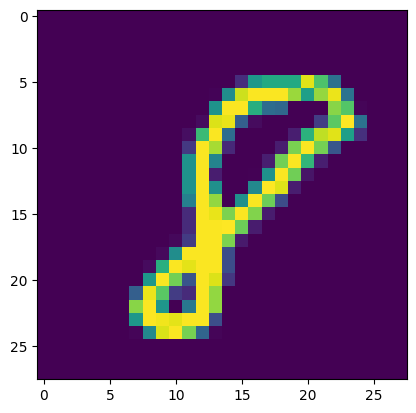

In [69]:
import matplotlib.pyplot as plt
import numpy as np

random_choice = np.random.randint(0, 5999)
print(one_hot_targets[random_choice])
plt.imshow(x[random_choice].reshape(28, 28))
plt.show()

In [75]:
model = SeqFrameworkTrainable()
model.add(Conv2DTrainable(1, 8, "relu", kernel_size=3))
model.add(Pool2DTrainable(mode="max", kernel_size=2))
model.add(Conv2DTrainable(8, 16, "relu", kernel_size=3))
model.add(Pool2DTrainable(mode="max", kernel_size=2))
model.add(Conv2DTrainable(16, 32, "relu", kernel_size=3))
model.add(Pool2DTrainable(mode="max", kernel_size=2))
model.add(FlattenMatrix())
model.add(NeuralNetworkTrainable(32, 16, "relu"))
model.add(NeuralNetworkTrainable(16, 10, "relu"))
model.add(SoftmaxLayer())

model.compile(loss="categorical_ce", lr=0.2, momentum=0.9)
model.fit(x, one_hot_targets, batch_size=64)

Compiled — loss: categorical_ce, optimizer: SGDMomentum(lr=0.2, momentum=0.9)

Layer          Activation         Params     Memory
conv2d         relu                   80      992 B
pool           -                       2      368 B
conv2d         relu                 1168    9.47 KB
pool           -                       2      368 B
conv2d         relu                 4640   36.59 KB
pool           -                       2      368 B
flatten        -                       2      368 B
neural         relu                  528    4.47 KB
neural         relu                  170    1.67 KB
softmax        -                       2      368 B
----------------------------------------------------------
Total                               6596   54.97 KB

Epoch 1/10 | Avg Loss: 1.309508 | Avg Acc: 0.5888                    
Epoch 2/10 | Avg Loss: 0.379488 | Avg Acc: 0.8868                    
Epoch 3/10 | Avg Loss: 0.263122 | Avg Acc: 0.9205                    
Epoch 4/10 | Avg Loss: 0.22

In [76]:
model.fit(x, one_hot_targets, batch_size=64)

Epoch 1/10 | Avg Loss: 0.133425 | Avg Acc: 0.9598                    
Epoch 2/10 | Avg Loss: 0.128668 | Avg Acc: 0.9607                    
Epoch 3/10 | Avg Loss: 0.122680 | Avg Acc: 0.9625                    
Epoch 4/10 | Avg Loss: 0.120320 | Avg Acc: 0.9629                    
Epoch 5/10 | Avg Loss: 0.116104 | Avg Acc: 0.9653                    
Epoch 6/10 | Avg Loss: 0.113066 | Avg Acc: 0.9658                    
Epoch 7/10 | Avg Loss: 0.108928 | Avg Acc: 0.9668                    
Epoch 8/10 | Avg Loss: 0.105719 | Avg Acc: 0.9684                    
Epoch 9/10 | Avg Loss: 0.105159 | Avg Acc: 0.9679                    
Epoch 10/10 | Avg Loss: 0.102742 | Avg Acc: 0.9688                    


In [77]:
model.fit(x, one_hot_targets, batch_size=64)

Epoch 1/10 | Avg Loss: 0.100360 | Avg Acc: 0.9694                    
Epoch 2/10 | Avg Loss: 0.096608 | Avg Acc: 0.9701                    
Epoch 3/10 | Avg Loss: 0.095308 | Avg Acc: 0.9707                    
Epoch 4/10 | Avg Loss: 0.094248 | Avg Acc: 0.9717                    
Epoch 5/10 | Avg Loss: 0.092633 | Avg Acc: 0.9716                    
Epoch 6/10 | Avg Loss: 0.090606 | Avg Acc: 0.9724                    
Epoch 7/10 | Avg Loss: 0.088948 | Avg Acc: 0.9723                    
Epoch 8/10 | Avg Loss: 0.086168 | Avg Acc: 0.9738                    
Epoch 9/10 | Avg Loss: 0.084941 | Avg Acc: 0.9738                    
Epoch 10/10 | Avg Loss: 0.083971 | Avg Acc: 0.9742                    


In [78]:
model.fit(x, one_hot_targets, 5, batch_size=64)

Epoch 1/5 | Avg Loss: 0.081878 | Avg Acc: 0.9748                    
Epoch 2/5 | Avg Loss: 0.082391 | Avg Acc: 0.9751                    
Epoch 3/5 | Avg Loss: 0.079420 | Avg Acc: 0.9756                    
Epoch 4/5 | Avg Loss: 0.078728 | Avg Acc: 0.9759                    
Epoch 5/5 | Avg Loss: 0.077483 | Avg Acc: 0.9765                    


In [106]:
model.evaluate(x, one_hot_targets)

Loss: 0.067667 | Accuracy: 0.9801


(0.06766721596121487, np.float64(0.9800830013833564))

In [107]:
import os
import json
import numpy as np
from datetime import datetime


def save_model_config(
    model,
    train_acc: float = 0.0,
    test_acc: float = 0.0,
    base_folder: str = "folder_results"
):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    folder_name = f"{base_folder}_{timestamp}"
    os.makedirs(folder_name, exist_ok=True)

    model_conf = model.get_models_config
    layers = model.get_models

    config_output = []

    for conf, layer in zip(model_conf, layers):
        name = conf["name"]
        idx = conf["index"]

        layer_name = f"{name}-{idx}"

        w_filename = None
        b_filename = None

        has_param = False

        try:
            weights, bias = layer.get_params

            if weights is not None and bias is not None:
                has_param = True

        except Exception:
            weights = None
            bias = None
            has_param = False

        if has_param:
            w_filename = f"{layer_name}-weights.npz"
            b_filename = f"{layer_name}-bias.npz"

            w_path = os.path.join(folder_name, w_filename)
            b_path = os.path.join(folder_name, b_filename)

            np.savez_compressed(w_path, weights=np.array(weights))
            np.savez_compressed(b_path, bias=np.array(bias))

            print(
                f"Saved {layer_name}: "
                f"W{np.array(weights).shape}, "
                f"b{np.array(bias).shape}"
            )
        else:
            print(f"Skipped {layer_name}: no trainable params")

        config_output.append({
            "name": layer_name,
            "wparam": w_filename,
            "bparam": b_filename,
            "activation": conf["activation"],
            "bytesize": str(conf["size"]),
            "forward": has_param
        })

    result_json = {
        "timestamp": timestamp,
        "trainaccuracy": float(train_acc),
        "testaccuracy": float(test_acc),
        "configuration": config_output
    }

    json_path = os.path.join(folder_name, "model_results.json")

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(result_json, f, indent=4)

    print(f"Model saved in folder: {folder_name}")

    return folder_name

In [92]:
model_conf = model.get_models_config
print(len(model_conf))
loss = model.loss_hist
acc = model.acc_hist
model_conf = model_conf

10


In [93]:
len(loss), len(acc)

(35, 35)

In [108]:
train_loss, train_acc = model.evaluate(x, one_hot_targets)

save_model_config(
    model=model,
    train_acc=train_acc,
    test_acc=0.0,
    base_folder="folder_results_mnist_results"
)

Loss: 0.067667 | Accuracy: 0.9801
Saved conv2d-1: W(8, 1, 3, 3), b(8,)
Saved pool-2: W(1,), b(1,)
Saved conv2d-3: W(16, 8, 3, 3), b(16,)
Saved pool-4: W(1,), b(1,)
Saved conv2d-5: W(32, 16, 3, 3), b(32,)
Saved pool-6: W(1,), b(1,)
Saved flatten-7: W(1,), b(1,)
Saved neural-8: W(32, 16), b(1, 16)
Saved neural-9: W(16, 10), b(1, 10)
Saved softmax-10: W(1,), b(1,)
Model saved in folder: folder_results_mnist_results_20260613_150008


'folder_results_mnist_results_20260613_150008'

In [109]:
!zip -r folder_results_mnist_results_20260613_150008.zip /kaggle/working/folder_results_mnist_results_20260613_150008


  adding: kaggle/working/folder_results_mnist_results_20260613_150008/ (stored 0%)
  adding: kaggle/working/folder_results_mnist_results_20260613_150008/pool-2-weights.npz (deflated 26%)
  adding: kaggle/working/folder_results_mnist_results_20260613_150008/softmax-10-weights.npz (deflated 26%)
  adding: kaggle/working/folder_results_mnist_results_20260613_150008/conv2d-5-bias.npz (deflated 7%)
  adding: kaggle/working/folder_results_mnist_results_20260613_150008/conv2d-3-bias.npz (deflated 12%)
  adding: kaggle/working/folder_results_mnist_results_20260613_150008/model_results.json (deflated 86%)
  adding: kaggle/working/folder_results_mnist_results_20260613_150008/pool-2-bias.npz (deflated 13%)
  adding: kaggle/working/folder_results_mnist_results_20260613_150008/pool-6-bias.npz (deflated 13%)
  adding: kaggle/working/folder_results_mnist_results_20260613_150008/conv2d-1-bias.npz (deflated 18%)
  adding: kaggle/working/folder_results_mnist_results_20260613_150008/flatten-7-weights.npz

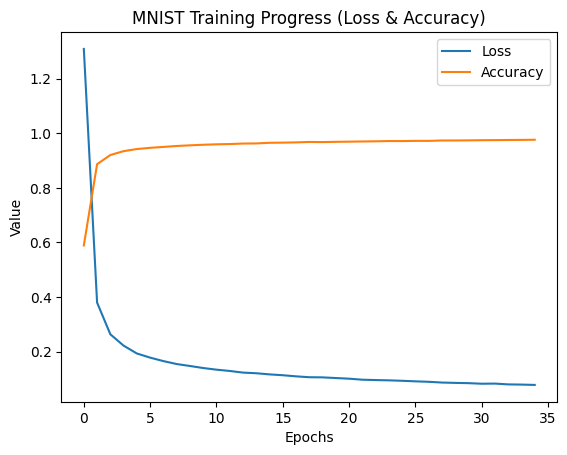

In [110]:
from matplotlib import pyplot as plt

l = loss
a = acc
t = [i for i in range(len(l))]

plt.plot(t, l, label='Loss')
plt.plot(t, a, label='Accuracy')

plt.title('MNIST Training Progress (Loss & Accuracy)')

plt.legend()

plt.xlabel('Epochs')
plt.ylabel('Value')

plt.savefig('plot_loss_folder_results_mnist_folder_results_mnist_results.png') 
plt.show()


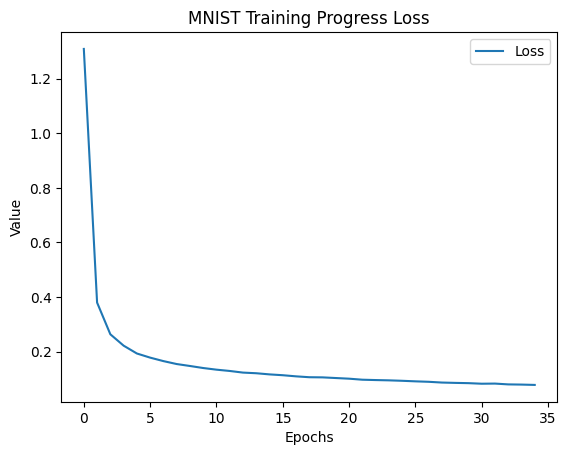

In [111]:
from matplotlib import pyplot as plt

l = loss
a = acc
t = [i for i in range(len(l))]

plt.plot(t, l, label='Loss')

plt.title('MNIST Training Progress Loss')

plt.legend()

plt.xlabel('Epochs')
plt.ylabel('Value')

plt.savefig('plot_loss_folder_results_mnist_folder_results_mnist_lost_results.png') 
plt.show()


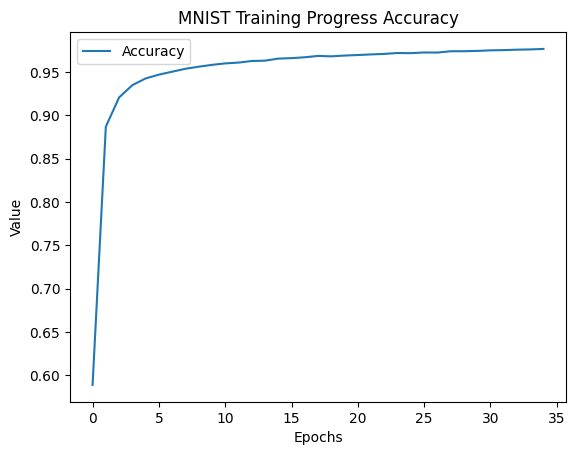

In [112]:
from matplotlib import pyplot as plt

l = loss
a = acc
t = [i for i in range(len(l))]

plt.plot(t, a, label='Accuracy')

plt.title('MNIST Training Progress Accuracy')

plt.legend()

plt.xlabel('Epochs')
plt.ylabel('Value')

plt.savefig('plot_loss_folder_results_mnist_folder_results_mnist_accuracy_results.png') 
plt.show()
